In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error,mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import SimpleExpSmoothing
from ipywidgets import interact,widgets
from statsmodels.tsa.api import Holt, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

In [32]:
train = pd.read_csv("Train_SU63ISt.csv")
test = pd.read_csv("Test_0qrQsBZ.csv")

In [33]:
print(train.head())
print(test.head())

   ID          Datetime  Count
0   0  25-08-2012 00:00      8
1   1  25-08-2012 01:00      2
2   2  25-08-2012 02:00      6
3   3  25-08-2012 03:00      2
4   4  25-08-2012 04:00      2
      ID          Datetime
0  18288  26-09-2014 00:00
1  18289  26-09-2014 01:00
2  18290  26-09-2014 02:00
3  18291  26-09-2014 03:00
4  18292  26-09-2014 04:00


#### Parse date column

In [34]:
train['Datetime'] = pd.to_datetime(train['Datetime'])
test['Datetime'] = pd.to_datetime(test['Datetime'])

train = train.sort_values(by='Datetime')
test = test.sort_values(by='Datetime')

train.set_index('Datetime', inplace=True)
test.set_index('Datetime', inplace=True)


/var/folders/zs/rgm7kj4s3bb8xy2q5rcm2pnh0000gn/T/ipykernel_2861/1455377471.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train['Datetime'] = pd.to_datetime(train['Datetime'])
/var/folders/zs/rgm7kj4s3bb8xy2q5rcm2pnh0000gn/T/ipykernel_2861/1455377471.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  test['Datetime'] = pd.to_datetime(test['Datetime'])


#### Visualize

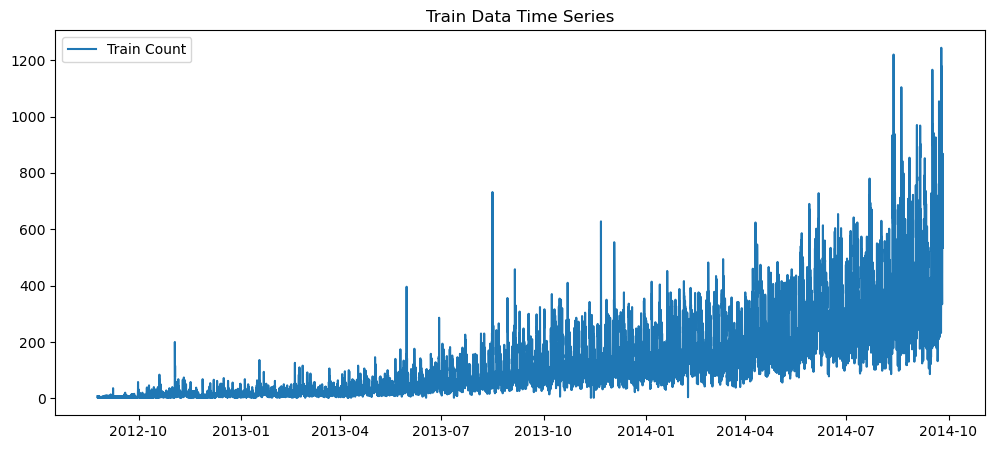

In [36]:
plt.figure(figsize=(12,5))
plt.plot(train['Count'], label='Train Count')
plt.title('Train Data Time Series')
plt.legend()
plt.show()

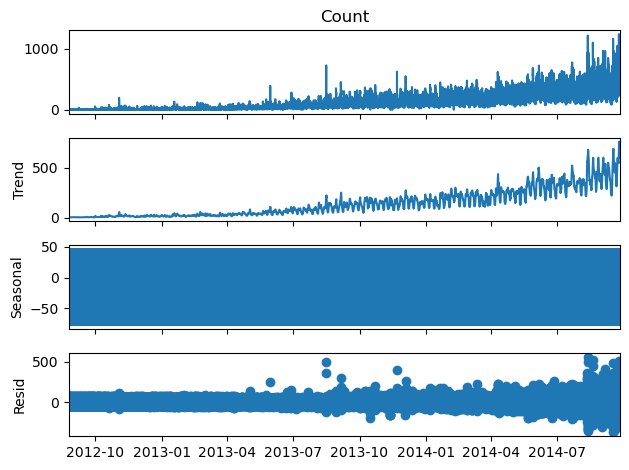

In [37]:
decomposition = seasonal_decompose(train['Count'], model='additive', period=24)
decomposition.plot()
plt.show()

#### Check for stationarity (ADF Test)

In [38]:
result = adfuller(train['Count'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
if result[1] < 0.05:
    print("✅ Series is stationary")
else:
    print("⚠️ Series is NOT stationary — differencing needed")


ADF Statistic: -4.456560536856818
p-value: 0.00023540466467665796
✅ Series is stationary


In [39]:
train_data = train.iloc[:-200]
val_data = train.iloc[-200:]


#### Apply different Time Series Models

#### 1 Simple Exponential Smoothing

In [40]:
ses_model = SimpleExpSmoothing(train_data['Count']).fit(smoothing_level=0.2, optimized=False)
ses_pred = ses_model.forecast(len(val_data))
rmse_ses = np.sqrt(mean_squared_error(val_data['Count'], ses_pred))
print(f"RMSE (Simple Exponential Smoothing): {rmse_ses:.3f}")


RMSE (Simple Exponential Smoothing): 271.129


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


#### Holt’s Linear Trend Method

In [41]:
holt_model = Holt(train_data['Count']).fit(smoothing_level=0.8, smoothing_trend=0.2)
holt_pred = holt_model.forecast(len(val_data))
rmse_holt = np.sqrt(mean_squared_error(val_data['Count'], holt_pred))
print(f"RMSE (Holt Linear): {rmse_holt:.3f}")


RMSE (Holt Linear): 1547.216


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


#### Holt-Winters Exponential Smoothing

In [42]:
hw_model = ExponentialSmoothing(train_data['Count'], trend='add', seasonal='add', seasonal_periods=24).fit()
hw_pred = hw_model.forecast(len(val_data))
rmse_hw = np.sqrt(mean_squared_error(val_data['Count'], hw_pred))
print(f"RMSE (Holt-Winters): {rmse_hw:.3f}")

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RMSE (Holt-Winters): 192.427


#### ARIMA 

In [43]:
arima_model = ARIMA(train_data['Count'], order=(2,1,2))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(len(val_data))
rmse_arima = np.sqrt(mean_squared_error(val_data['Count'], arima_pred))
print(f"RMSE (ARIMA): {rmse_arima:.3f}")

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


RMSE (ARIMA): 294.164


#### Compare Results

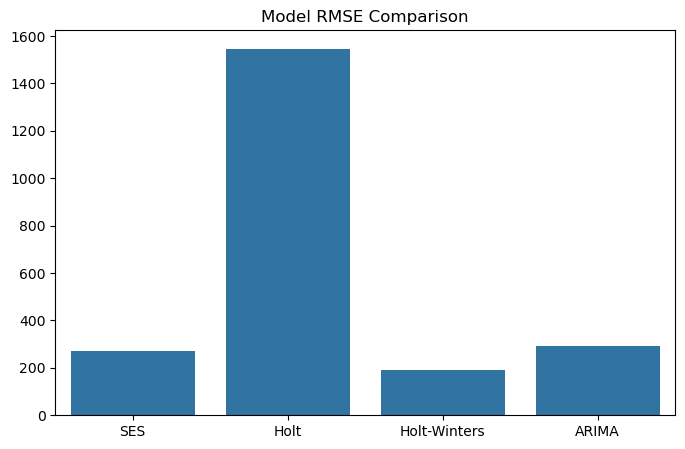

In [44]:
models = ['SES', 'Holt', 'Holt-Winters', 'ARIMA']
rmse_values = [rmse_ses, rmse_holt, rmse_hw, rmse_arima]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=rmse_values)
plt.title("Model RMSE Comparison")
plt.show()

#### Predict on Test Dataset (Best Model)

In [30]:
best_model = ExponentialSmoothing(train['Count'], trend='add', seasonal='add', seasonal_periods=24).fit()
test_pred = best_model.forecast(len(test))
test_pred

18288    493.280127
18289    399.511254
18290    366.603156
18291    328.413406
18292    306.115281
            ...    
23395    871.919759
23396    781.090001
23397    742.566198
23398    724.974644
23399    752.102958
Length: 5112, dtype: float64